In [27]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os

load_dotenv()

os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

llm = ChatGroq(model="qwen/qwen3-32b")


In [59]:
from pydantic import BaseModel, Field
from typing import Optional, Literal

class State(BaseModel):
    topic: str = Field(description="Topic on which joke need to be cracked")
    joke: Optional[str] = Field(default=None, description="Content of the joke")
    feedback: Optional[str] = Field(default=None, description="Feedback on the joke")
    attempts: Optional[int] = Field(default=0, description="Number of attempts to generate a funny joke")
    funny_or_not: Optional[str] = Field(default=None, description="Indicator if the joke is funny or not")

class Feedback(BaseModel):
    feedback: str  = Field(description="If joke is not funny, provide feedback to improve the joke")
    grade: Literal['Funny', 'Not Funny'] = Field(description="Indicator if the joke is funny or not")


evaluator = llm.with_structured_output(Feedback)

In [60]:
from langchain.messages import HumanMessage, SystemMessage

## Nodes
def joke_generator(state: State):
    """Generate a joke based on the topic"""
    content = f"Write a very funny joke on {state.topic}"
    if state.feedback:
        content = f"{content} and along account {state.feedback} feedback."


    joke = llm.invoke(
        [
            SystemMessage(content="Act a very comical script writer."),
            HumanMessage(content=content)
        ]
    )
    print(joke.content)
    return {"joke": joke.content, "attempts": state.attempts + 1}


def joke_evaluator(state: State):
    """Evaluate if the joke is funny or not funny based and provide appropriate feedback"""
    feedback = evaluator.invoke(
        [
            SystemMessage(content="Act as a critical joke critic."),
            HumanMessage(content=f"Evaluate the joke {state.joke} properly. If it is not funny then provide appropriate feedback.")
        ]
    )
    return {"funny_or_not": feedback.grade, "feedback": feedback.feedback}


def route_joke(state: State):
    """Route back to joke generator or end based upon feedback from the evaluator."""
    if (state.funny_or_not != None and state.funny_or_not.lower() == "funny") or state.attempts > 3:
        return "Accepted"
    else:
        return "Rejected + Feedback"

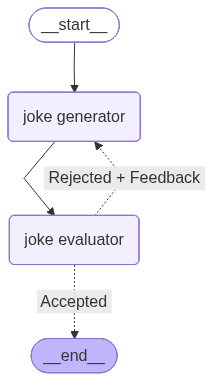

In [61]:
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

joke_builder = StateGraph(State)

joke_builder.add_node("joke generator", joke_generator)
joke_builder.add_node("joke evaluator", joke_evaluator)

joke_builder.add_edge(START, "joke generator")
joke_builder.add_edge("joke generator", "joke evaluator")
joke_builder.add_conditional_edges("joke evaluator", route_joke, {"Accepted": END, "Rejected + Feedback": "joke generator"})

joke_box = joke_builder.compile()

display(Image(joke_box.get_graph().draw_mermaid_png()))


In [63]:
joke_box.invoke({"topic": "cat"})

<think>
Okay, I need to come up with a funny joke about a cat. Let's start by brainstorming some cat-related topics. Cats are known for their aloofness, their love of knocking things over, their obsession with boxes, and their weird food preferences. Maybe I can play on some of these traits.

Let me think about common joke structures. A classic setup and punchline, maybe with some wordplay. The user wants it comical, so maybe a bit of exaggeration. Maybe something about a cat's meowing. Wait, there's a joke about meowing... "Why did the cat meow? Because he wanted to talk to his brother!" No, that's not funny. Let's try another angle.

How about the cat's owner? Maybe the cat is the boss. Like, the cat makes the owner do things. Maybe a play on the phrase "the cat's meow." Wait, "the cat's meow" means something is great. Maybe flip it. Like, the cat wants something and the owner has to comply. 

What if the cat is demanding and the owner is like a servant. Maybe a joke where the cat sa

{'topic': 'cat',
 'joke': '<think>\nOkay, I need to come up with a funny joke about a cat. Let\'s start by brainstorming some cat-related topics. Cats are known for their aloofness, their love of knocking things over, their obsession with boxes, and their weird food preferences. Maybe I can play on some of these traits.\n\nLet me think about common joke structures. A classic setup and punchline, maybe with some wordplay. The user wants it comical, so maybe a bit of exaggeration. Maybe something about a cat\'s meowing. Wait, there\'s a joke about meowing... "Why did the cat meow? Because he wanted to talk to his brother!" No, that\'s not funny. Let\'s try another angle.\n\nHow about the cat\'s owner? Maybe the cat is the boss. Like, the cat makes the owner do things. Maybe a play on the phrase "the cat\'s meow." Wait, "the cat\'s meow" means something is great. Maybe flip it. Like, the cat wants something and the owner has to comply. \n\nWhat if the cat is demanding and the owner is lik